# Wer klatscht für wen?

Der Bundestag veröffentlicht jedes Plenarprotokoll als strukturiertes XML ([Open Data Portal](https://www.bundestag.de/services/opendata)). Jede Reaktion des Plenums — Beifall, Zurufe, Lachen, Heiterkeit, Widerspruch — steht als `<kommentar>`-Element **innerhalb der Rede**, die sie unterbrochen hat. Damit lässt sich rekonstruieren: *welche Fraktion reagiert wie auf wen*.

Datenbasis: alle Sitzungen der 21. Wahlperiode (seit März 2025), heruntergeladen mit `scripts/download_protocols.py`, geparst von `btd/parse.py`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

from btd.frames import FRAKTIONEN, PARTY_COLORS, interaction_matrix, load_frames

# chart chrome tokens
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "sans-serif", "font.size": 11,
})
BLUES = LinearSegmentedColormap.from_list("seq_blue", ["#f4f9ff", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
REDS = LinearSegmentedColormap.from_list("seq_red", ["#fff5f4", "#fbdddd", "#f5b4b3", "#ee8a89", "#e65e5d", "#d63938", "#b02322", "#8a1a1a"])

speeches, events = load_frames(Path("../data/protocols"), wahlperiode=21)
print(f"{speeches['sitzung'].nunique()} Sitzungen · {len(speeches):,} Reden · {len(events):,} Kommentar-Ereignisse")
events["kind"].value_counts()

90 Sitzungen · 12,090 Reden · 142,825 Kommentar-Ereignisse


kind
beifall        86801
zuruf          50652
lachen          1726
heiterkeit      1630
other           1606
widerspruch      410
Name: count, dtype: int64

## Die Beifall-Matrix

Für jede Rede wissen wir, wer am Pult stand und welche Fraktionen applaudiert haben. Normiert auf *Beifall pro gehaltener Rede*, damit Fraktionen mit viel Redezeit das Bild nicht verzerren. Teilbeifall („bei Abgeordneten der X\") zählt halb.


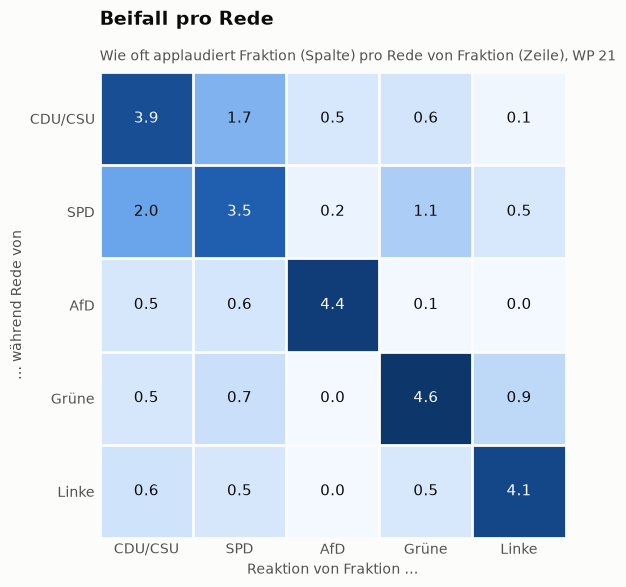

In [2]:
def plot_matrix(matrix, cmap, title, subtitle, fmt="{:.1f}"):
    fig, ax = plt.subplots(figsize=(7.2, 6))
    values = matrix.to_numpy()
    im = ax.imshow(values, cmap=cmap, aspect="equal")
    ax.set_xticks(range(len(matrix.columns)), matrix.columns, fontsize=10)
    ax.set_yticks(range(len(matrix.index)), matrix.index, fontsize=10)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    threshold = values.min() + 0.55 * (values.max() - values.min())
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            color = "#ffffff" if values[i, j] > threshold else INK
            ax.text(j, i, fmt.format(values[i, j]), ha="center", va="center", color=color, fontsize=11)
    ax.set_xlabel("Reaktion von Fraktion …", fontsize=10)
    ax.set_ylabel("… während Rede von", fontsize=10)
    ax.set_title(title, fontsize=14, fontweight="bold", loc="left", pad=34)
    ax.text(0, 1.025, subtitle, transform=ax.transAxes, fontsize=10, color=INK2)
    # 2px white gaps between cells
    ax.set_xticks(np.arange(-0.5, len(matrix.columns)), minor=True)
    ax.set_yticks(np.arange(-0.5, len(matrix.index)), minor=True)
    ax.grid(which="minor", color=SURFACE, linewidth=2)
    ax.tick_params(which="minor", length=0)
    fig.tight_layout()
    return fig

beifall = interaction_matrix(events, speeches, "beifall")
plot_matrix(beifall, BLUES, "Beifall pro Rede", "Wie oft applaudiert Fraktion (Spalte) pro Rede von Fraktion (Zeile), WP 21");

Erwartbar: die Diagonale dominiert — Fraktionen beklatschen sich selbst. Interessant sind die Nebendiagonalen: die Koalition (CDU/CSU ↔ SPD) klatscht füreinander, die AfD bekommt von niemandem Applaus außer von sich selbst, und Grüne ↔ Linke stützen sich gegenseitig.


## Die Zuruf-Matrix: wer stört wen?


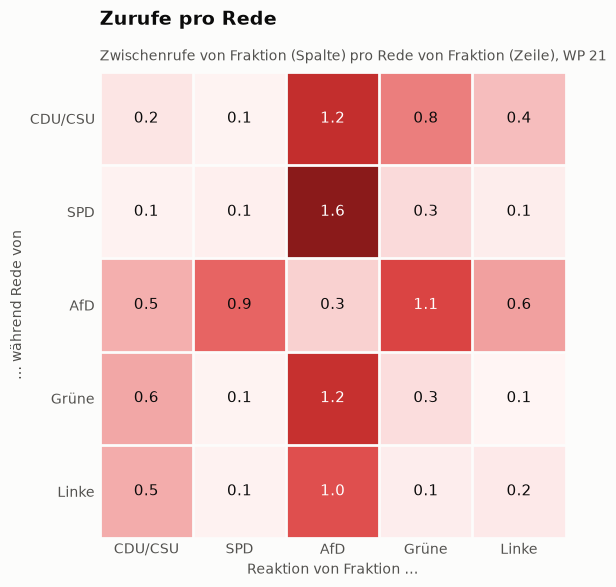

In [3]:
zurufe = interaction_matrix(events, speeches, "zuruf")
plot_matrix(zurufe, REDS, "Zurufe pro Rede", "Zwischenrufe von Fraktion (Spalte) pro Rede von Fraktion (Zeile), WP 21");

## Die meistbeklatschten Redner:innen

Beifall pro Rede, mindestens 10 Reden. Regierungsmitglieder tragen die Farbe ihrer Partei nicht — sie sprechen ohne Fraktionszugehörigkeit im Protokoll, daher grau.


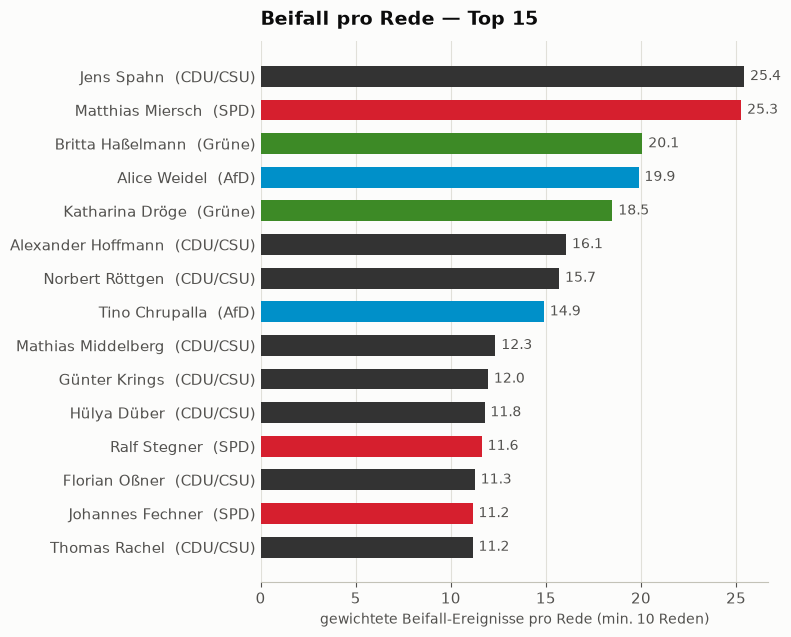

In [4]:
per_speaker = (
    events[events["kind"] == "beifall"]
    .groupby(["to_speaker", "to_party"], as_index=False)["weight"].sum()
    .merge(
        speeches.groupby(["speaker", "party"]).size().rename("n_reden").reset_index(),
        left_on=["to_speaker", "to_party"], right_on=["speaker", "party"],
    )
)
per_speaker = per_speaker[per_speaker["n_reden"] >= 10]
per_speaker["rate"] = per_speaker["weight"] / per_speaker["n_reden"]
top = per_speaker.nlargest(15, "rate").iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6.5))
colors = [PARTY_COLORS.get(p, MUTED) for p in top["to_party"]]
bars = ax.barh(top["to_speaker"] + "  (" + top["to_party"] + ")", top["rate"], color=colors, height=0.62)
for bar, value in zip(bars, top["rate"]):
    ax.text(bar.get_width() + top["rate"].max() * 0.012, bar.get_y() + bar.get_height() / 2, f"{value:.1f}", va="center", fontsize=10, color=INK2)
ax.set_title("Beifall pro Rede — Top 15", fontsize=14, fontweight="bold", loc="left", pad=12)
ax.set_xlabel("gewichtete Beifall-Ereignisse pro Rede (min. 10 Reden)", fontsize=10)
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
fig.tight_layout()

## Die fleißigsten Zwischenrufer:innen

Namentlich protokollierte Zurufe — das Stenografenteam schreibt auf, *wer* ruft.


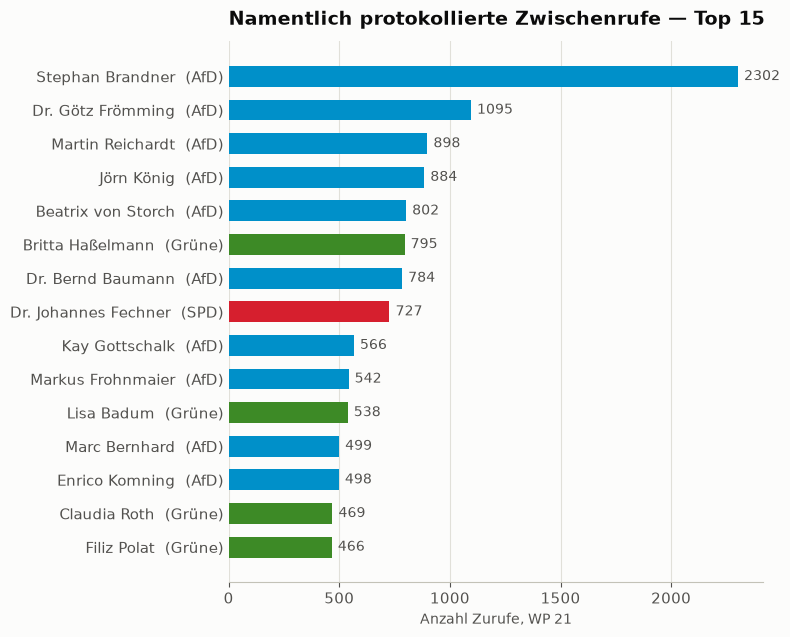

In [5]:
named = events[(events["kind"] == "zuruf") & (events["person"] != "")]
hecklers = named.groupby(["person", "party"]).size().rename("n").reset_index().nlargest(15, "n").iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6.5))
colors = [PARTY_COLORS.get(p, MUTED) for p in hecklers["party"]]
bars = ax.barh(hecklers["person"] + "  (" + hecklers["party"] + ")", hecklers["n"], color=colors, height=0.62)
for bar, value in zip(bars, hecklers["n"]):
    ax.text(bar.get_width() + hecklers["n"].max() * 0.012, bar.get_y() + bar.get_height() / 2, str(value), va="center", fontsize=10, color=INK2)
ax.set_title("Namentlich protokollierte Zwischenrufe — Top 15", fontsize=14, fontweight="bold", loc="left", pad=12)
ax.set_xlabel("Anzahl Zurufe, WP 21", fontsize=10)
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
fig.tight_layout()

## Eigenapplaus

Welcher Anteil des Beifalls, den eine Fraktion bekommt, kommt aus den eigenen Reihen?


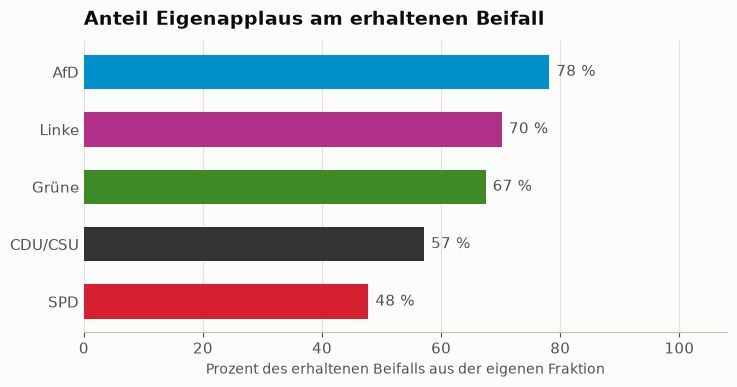

In [6]:
received = events[(events["kind"] == "beifall") & events["party"].isin(FRAKTIONEN) & events["to_party"].isin(FRAKTIONEN)]
totals = received.groupby("to_party")["weight"].sum()
own = received[received["party"] == received["to_party"]].groupby("to_party")["weight"].sum()
share = (own / totals).reindex(FRAKTIONEN).sort_values()

fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.barh(share.index, share * 100, color=[PARTY_COLORS[p] for p in share.index], height=0.6)
for bar, value in zip(bars, share * 100):
    ax.text(bar.get_width() + 1.2, bar.get_y() + bar.get_height() / 2, f"{value:.0f} %", va="center", fontsize=11, color=INK2)
ax.set_title("Anteil Eigenapplaus am erhaltenen Beifall", fontsize=14, fontweight="bold", loc="left", pad=12)
ax.set_xlim(0, 108)
ax.set_xlabel("Prozent des erhaltenen Beifalls aus der eigenen Fraktion", fontsize=10)
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
fig.tight_layout()

## Was gerufen wird

Die Stenograf:innen protokollieren Zurufe teils wörtlich — eine Stichprobe der häufigsten.


In [7]:
quotes = events[events["quote"] != ""]
print(f"{len(quotes):,} wörtlich protokollierte Zurufe\n")
quotes["quote"].value_counts().head(15)

38,074 wörtlich protokollierte Zurufe



quote
Genau!               356
Ja!                  346
So ist es!           322
Hört! Hört!          250
Richtig!             200
Nein!                135
Sehr gut!            123
Aha!                 117
Sehr richtig!        106
Doch!                100
Quatsch!              89
Was?                  88
Oh!                   79
Das stimmt nicht!     67
So ein Quatsch!       65
Name: count, dtype: int64

## Ideen für bundestagsdaten.de

- **Beifall-Matrix live**: die Matrix oben als interaktives Herzstück, filterbar nach Zeitraum/Thema — zeigt Koalitionsdynamik auf einen Blick
- **Abgeordneten-Profile**: pro MdB Beifall-/Zuruf-Bilanz, wer applaudiert ihnen, wen unterbrechen sie (Join mit MDB-Stammdaten für Foto, Wahlkreis, Alter)
- **Zeitreihen**: Polarisierung messbar? Anteil Fraktionsgrenzen-überschreitenden Beifalls über die Zeit, WP 20 vs 21 (WP-20-Daten: `download_protocols.py 20`)
- **Themen × Reaktion**: Tagesordnungspunkte klassifizieren — bei welchen Themen lacht das Haus, bei welchen wird gebrüllt?
- **Redezeit-Analysen**: Reden pro MdB, Redelänge, Anteil Regierungsmitglieder
- **Wortweite Analysen** (DIP-API als zweite Quelle): Vokabular pro Fraktion, namentliche Abstimmungen, Drucksachen-Verweise
- **„Zuruf des Tages\"**: kuratierte wörtliche Zwischenrufe als Social-Media-taugliches Feature
